Inconsistency at edge B -> E
6 > 1 + 2
False


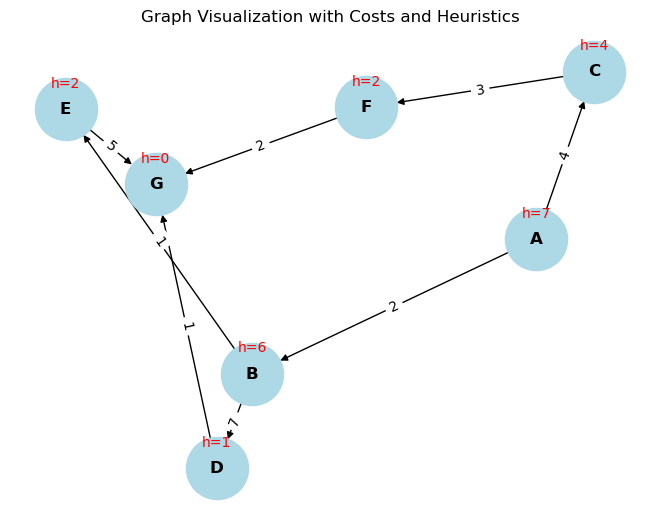

In [23]:
#TASK 01
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 7, 'E': 1},
    'C': {'F': 3},
    'D': {'G': 1},
    'E': {'G': 5},
    'F': {'G': 2},
    'G': {}
}

heuristic_table = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 1,
    'E': 2,
    'F': 2,
    'G': 0
}

def h(node):
    return heuristic_table[node]

def check_consistency(graph, heuristic):
    consistent = True
    for node in graph:
        for neighbor, cost in graph[node].items():
            if heuristic[node] > cost + heuristic[neighbor]:
                print(f"Inconsistency at edge {node} -> {neighbor}")
                print(f"{heuristic[node]} > {cost} + {heuristic[neighbor]}")
                consistent = False
    return consistent

print(check_consistency(graph, heuristic_table))

G = nx.DiGraph()

for node in graph:
    for neighbor, cost in graph[node].items():
        G.add_edge(node, neighbor, weight=cost)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=2000, font_size=12, font_weight='bold')

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

for node, (x, y) in pos.items():
    plt.text(x, y + 0.08, f"h={heuristic_table[node]}",
             horizontalalignment='center', fontsize=10, color='red')

plt.title("Graph Visualization with Costs and Heuristics")
plt.show()

GBFS Expansion Order: ['A', 'C', 'F', 'G']
GBFS Path: ['A', 'C', 'F', 'G']
GBFS Total Cost: 9


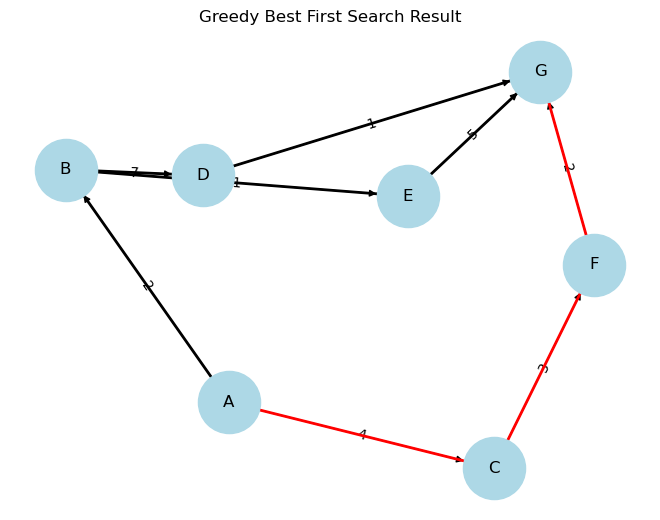


BFS Expansion Order: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
BFS Path: ['A', 'B', 'D', 'G']
BFS Total Cost: 10


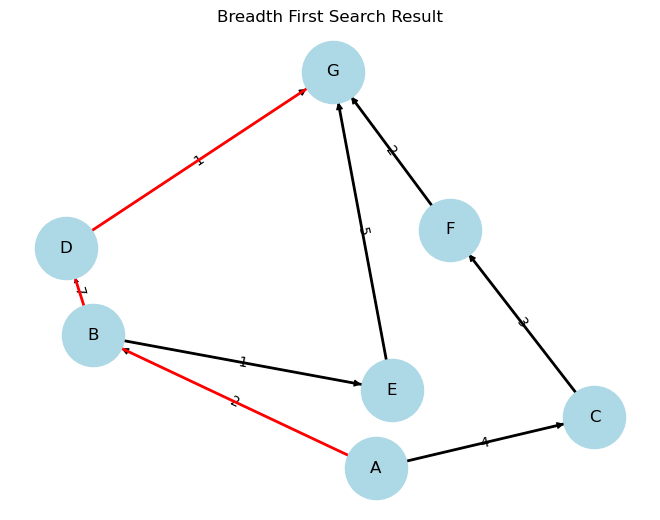

In [15]:
#TASK 02
import heapq
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 7, 'E': 1},
    'C': {'F': 3},
    'D': {'G': 1},
    'E': {'G': 5},
    'F': {'G': 2},
    'G': {}
}

heuristic_table = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 1,
    'E': 2,
    'F': 2,
    'G': 0
}

def reconstruct_path(came_from, current):
    path = []
    while current is not None:
        path.append(current)
        current = came_from[current]
    path.reverse()
    return path

def greedy_best_first_search(start, goal, graph, heuristic):
    frontier = []
    heapq.heappush(frontier, (heuristic[start], start))
    came_from = {start: None}
    explored = set()
    expansion_order = []

    while frontier:
        _, current = heapq.heappop(frontier)
        if current in explored:
            continue
        expansion_order.append(current)
        explored.add(current)

        if current == goal:
            return reconstruct_path(came_from, current), expansion_order

        for neighbor in graph[current]:
            if neighbor not in explored:
                heapq.heappush(frontier, (heuristic[neighbor], neighbor))
                if neighbor not in came_from:
                    came_from[neighbor] = current

    return None, expansion_order

def bfs(start, goal, graph):
    queue = deque([start])
    came_from = {start: None}
    expansion_order = []

    while queue:
        current = queue.popleft()
        expansion_order.append(current)

        if current == goal:
            return reconstruct_path(came_from, current), expansion_order

        for neighbor in graph[current]:
            if neighbor not in came_from:
                queue.append(neighbor)
                came_from[neighbor] = current

    return None, expansion_order

def compute_path_cost(path, graph):
    total = 0
    for i in range(len(path) - 1):
        total += graph[path[i]][path[i+1]]
    return total

def visualize(graph, path, title):
    G = nx.DiGraph()
    for node in graph:
        for neighbor, cost in graph[node].items():
            G.add_edge(node, neighbor, weight=cost)

    pos = nx.spring_layout(G)

    edge_colors = []
    path_edges = []
    if path:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]

    for edge in G.edges():
        if edge in path_edges:
            edge_colors.append("red")
        else:
            edge_colors.append("black")

    nx.draw(G, pos, with_labels=True, node_color="lightblue",
            node_size=2000, font_size=12)

    nx.draw_networkx_edge_labels(G, pos,
                                 edge_labels=nx.get_edge_attributes(G, 'weight'))

    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2)

    plt.title(title)
    plt.show()

start = 'A'
goal = 'G'

gbfs_path, gbfs_expansion = greedy_best_first_search(start, goal, graph, heuristic_table)
gbfs_cost = compute_path_cost(gbfs_path, graph)

print("GBFS Expansion Order:", gbfs_expansion)
print("GBFS Path:", gbfs_path)
print("GBFS Total Cost:", gbfs_cost)

visualize(graph, gbfs_path, "Greedy Best First Search Result")

bfs_path, bfs_expansion = bfs(start, goal, graph)
bfs_cost = compute_path_cost(bfs_path, graph)

print("\nBFS Expansion Order:", bfs_expansion)
print("BFS Path:", bfs_path)
print("BFS Total Cost:", bfs_cost)

visualize(graph, bfs_path, "Breadth First Search Result")


--- Greedy Best First Search ---
Expansion Order: ['A', 'C', 'F', 'G']
Path: ['A', 'C', 'F', 'G']
Total Cost: 9

--- A* Search ---
Expansion Order: ['A', 'B', 'E', 'C', 'G']
Path: ['A', 'B', 'E', 'G']
Total Cost: 8


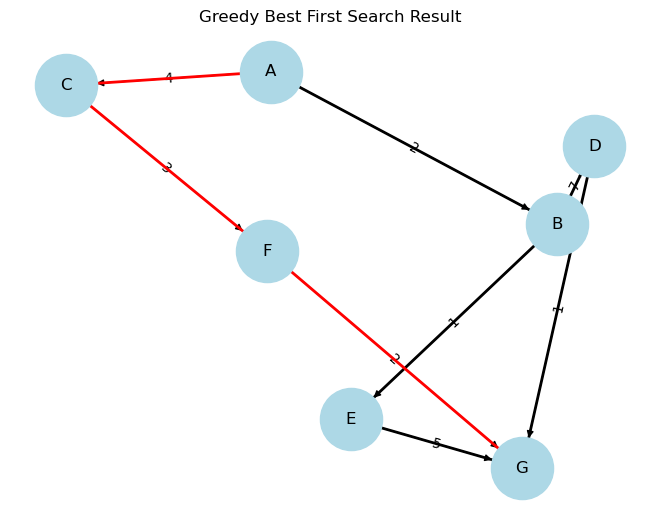

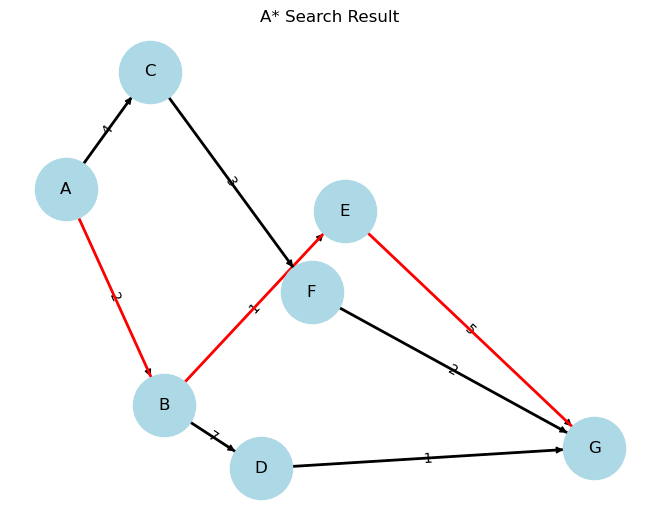

In [16]:
#TASK 03
import heapq
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 7, 'E': 1},
    'C': {'F': 3},
    'D': {'G': 1},
    'E': {'G': 5},
    'F': {'G': 2},
    'G': {}
}

heuristic_table = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 1,
    'E': 2,
    'F': 2,
    'G': 0
}

def reconstruct_path(came_from, current):
    path = []
    while current is not None:
        path.append(current)
        current = came_from[current]
    path.reverse()
    return path

def greedy_best_first_search(start, goal, graph, heuristic):
    frontier = []
    heapq.heappush(frontier, (heuristic[start], start))
    came_from = {start: None}
    explored = set()
    expansion_order = []

    while frontier:
        _, current = heapq.heappop(frontier)

        if current in explored:
            continue

        expansion_order.append(current)
        explored.add(current)

        if current == goal:
            return reconstruct_path(came_from, current), expansion_order

        for neighbor in graph[current]:
            if neighbor not in explored:
                heapq.heappush(frontier, (heuristic[neighbor], neighbor))
                if neighbor not in came_from:
                    came_from[neighbor] = current

    return None, expansion_order

def a_star_search(start, goal, graph, heuristic):
    frontier = []
    heapq.heappush(frontier, (heuristic[start], start))
    came_from = {start: None}
    g_costs = {start: 0}
    expansion_order = []

    while frontier:
        current_f, current = heapq.heappop(frontier)
        expansion_order.append(current)

        if current == goal:
            return reconstruct_path(came_from, current), g_costs[current], expansion_order

        for neighbor, cost in graph[current].items():
            tentative_g = g_costs[current] + cost

            if neighbor not in g_costs or tentative_g < g_costs[neighbor]:
                g_costs[neighbor] = tentative_g
                f_score = tentative_g + heuristic[neighbor]
                heapq.heappush(frontier, (f_score, neighbor))
                came_from[neighbor] = current

    return None, 0, expansion_order

def compute_cost(path, graph):
    total = 0
    for i in range(len(path) - 1):
        total += graph[path[i]][path[i+1]]
    return total

def visualize(graph, path, title):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, cost in graph[node].items():
            G.add_edge(node, neighbor, weight=cost)

    pos = nx.spring_layout(G)

    path_edges = []
    if path:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]

    edge_colors = []
    for edge in G.edges():
        if edge in path_edges:
            edge_colors.append("red")
        else:
            edge_colors.append("black")

    nx.draw(G, pos, with_labels=True, node_color="lightblue",
            node_size=2000, font_size=12)

    nx.draw_networkx_edge_labels(G, pos,
                                 edge_labels=nx.get_edge_attributes(G, 'weight'))

    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2)

    plt.title(title)
    plt.show()

start = 'A'
goal = 'G'

gbfs_path, gbfs_expansion = greedy_best_first_search(start, goal, graph, heuristic_table)
gbfs_cost = compute_cost(gbfs_path, graph)

astar_path, astar_cost, astar_expansion = a_star_search(start, goal, graph, heuristic_table)

print("\n--- Greedy Best First Search ---")
print("Expansion Order:", gbfs_expansion)
print("Path:", gbfs_path)
print("Total Cost:", gbfs_cost)

print("\n--- A* Search ---")
print("Expansion Order:", astar_expansion)
print("Path:", astar_path)
print("Total Cost:", astar_cost)

visualize(graph, gbfs_path, "Greedy Best First Search Result")
visualize(graph, astar_path, "A* Search Result")


--- Weighted A* (w = 1.0) ---
Expansion Order: ['A', 'B', 'E', 'C', 'G']
Path: ['A', 'B', 'E', 'G']
Total Cost: 8
Nodes Expanded: 5


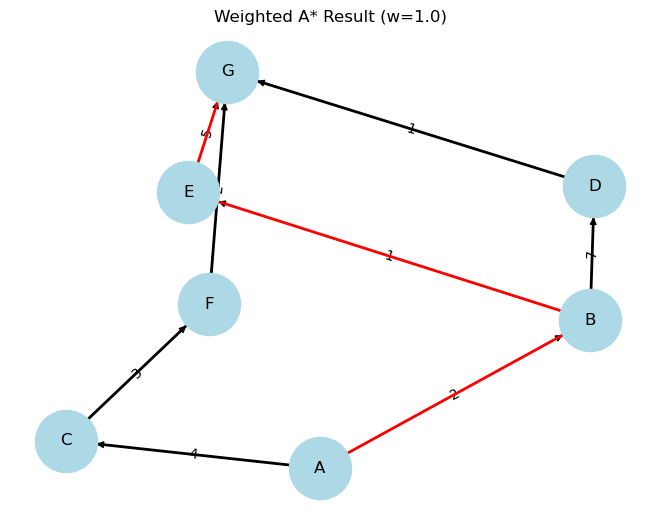


--- Weighted A* (w = 1.5) ---
Expansion Order: ['A', 'C', 'F', 'G']
Path: ['A', 'C', 'F', 'G']
Total Cost: 9
Nodes Expanded: 4


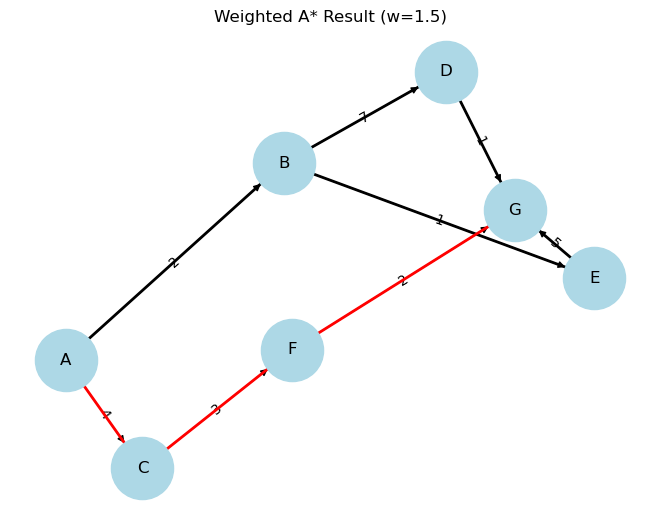


--- Weighted A* (w = 2.0) ---
Expansion Order: ['A', 'C', 'F', 'G']
Path: ['A', 'C', 'F', 'G']
Total Cost: 9
Nodes Expanded: 4


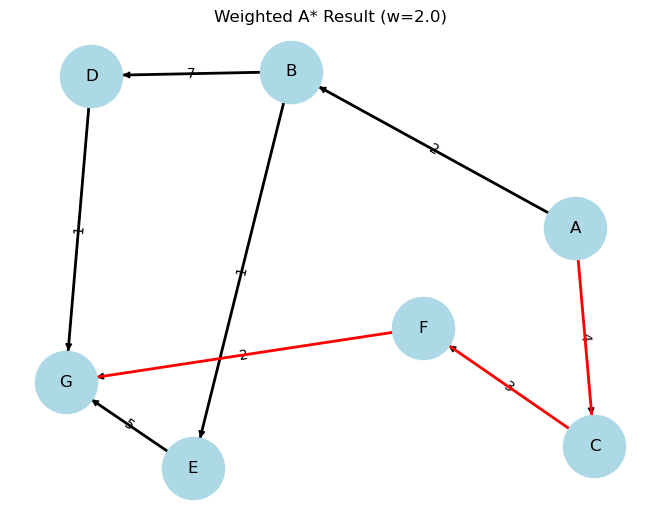

In [17]:
#TASK 04
import heapq
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 7, 'E': 1},
    'C': {'F': 3},
    'D': {'G': 1},
    'E': {'G': 5},
    'F': {'G': 2},
    'G': {}
}

heuristic_table = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 1,
    'E': 2,
    'F': 2,
    'G': 0
}

def reconstruct_path(came_from, current):
    path = []
    while current is not None:
        path.append(current)
        current = came_from[current]
    path.reverse()
    return path

def weighted_a_star(start, goal, graph, heuristic, w):
    frontier = []
    heapq.heappush(frontier, (w * heuristic[start], start))
    came_from = {start: None}
    g_costs = {start: 0}
    expansion_order = []

    while frontier:
        current_f, current = heapq.heappop(frontier)
        expansion_order.append(current)

        if current == goal:
            return reconstruct_path(came_from, current), g_costs[current], expansion_order

        for neighbor, cost in graph[current].items():
            tentative_g = g_costs[current] + cost

            if neighbor not in g_costs or tentative_g < g_costs[neighbor]:
                g_costs[neighbor] = tentative_g
                f_score = tentative_g + w * heuristic[neighbor]
                heapq.heappush(frontier, (f_score, neighbor))
                came_from[neighbor] = current

    return None, 0, expansion_order

def visualize(graph, path, title):
    G = nx.DiGraph()
    for node in graph:
        for neighbor, cost in graph[node].items():
            G.add_edge(node, neighbor, weight=cost)

    pos = nx.spring_layout(G)

    path_edges = []
    if path:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]

    edge_colors = ["red" if edge in path_edges else "black" for edge in G.edges()]

    nx.draw(G, pos, with_labels=True, node_color="lightblue",
            node_size=2000, font_size=12)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2)

    plt.title(title)
    plt.show()

weights = [1.0, 1.5, 2.0]

for w in weights:
    path, cost, expansion = weighted_a_star('A', 'G', graph, heuristic_table, w)
    print(f"\n--- Weighted A* (w = {w}) ---")
    print("Expansion Order:", expansion)
    print("Path:", path)
    print("Total Cost:", cost)
    print("Nodes Expanded:", len(expansion))
    visualize(graph, path, f"Weighted A* Result (w={w})")

Order of Node Expansions: ['A', 'B', 'E', 'I', 'K']
Solution Path: A -> B -> E -> I -> K
Total Path Cost: 10


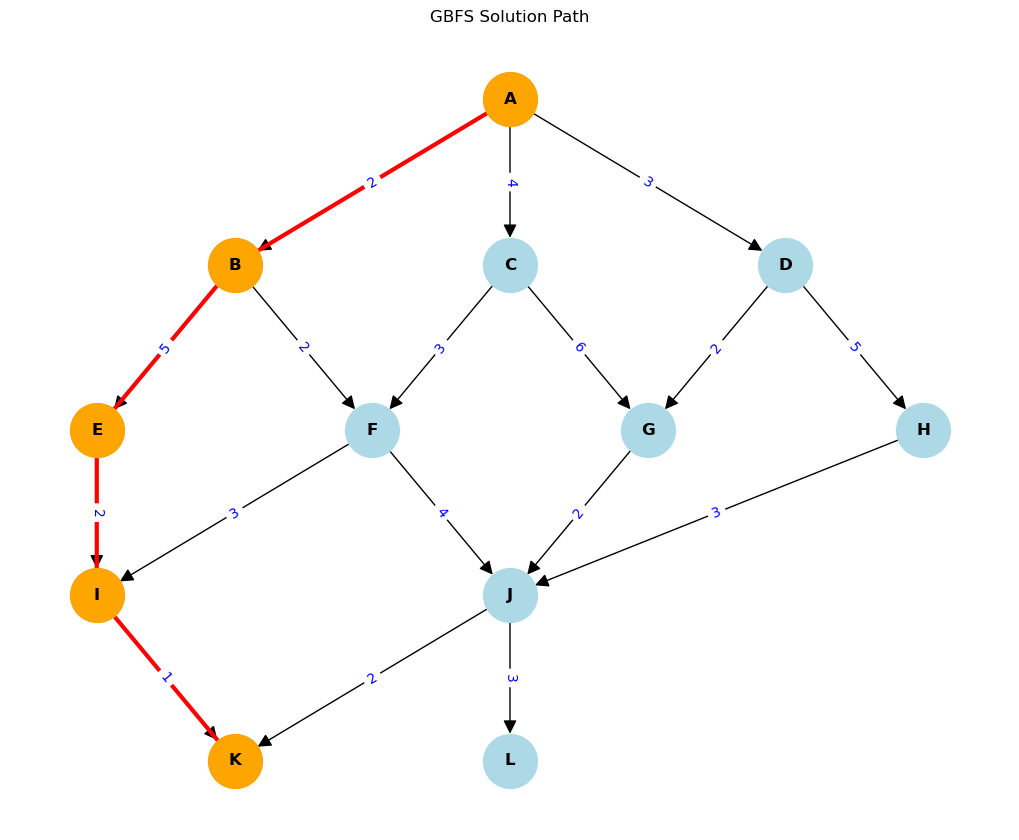

In [19]:
#TASK 05 Part 01
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Define the graph based on the image
graph = {
    'A': {'B': 2, 'C': 4, 'D': 3},
    'B': {'E': 5, 'F': 2},
    'C': {'F': 3, 'G': 6},
    'D': {'G': 2, 'H': 5},
    'E': {'I': 2},
    'F': {'I': 3, 'J': 4},
    'G': {'J': 2},
    'H': {'J': 3},
    'I': {'K': 1},
    'J': {'K': 2, 'L': 3},
    'K': {},
    'L': {}
}

# Heuristic values h(n)
heuristics = {
    'A': 5, 'B': 4, 'C': 4, 'D': 4,
    'E': 2, 'F': 2, 'G': 2, 'H': 3,
    'I': 1, 'J': 1, 'K': 0, 'L': 0
}

def greedy_best_first_search(start, goals, graph, h):
    # frontier stores (heuristic, current_node)
    frontier = [(h[start], start)]
    came_from = {start: None}
    expansion_order = []
    
    while frontier:
        # Pop the node with the smallest h(n)
        current_h, current = heapq.heappop(frontier)
        expansion_order.append(current)

        # Check if we reached any goal
        if current in goals:
            path = []
            temp = current
            while temp is not None:
                path.append(temp)
                temp = came_from[temp]
            return path[::-1], expansion_order

        for neighbor in graph[current]:
            if neighbor not in came_from:
                came_from[neighbor] = current
                heapq.heappush(frontier, (h[neighbor], neighbor))
                
    return None, expansion_order

def calculate_cost(path, graph):
    total = 0
    for i in range(len(path) - 1):
        total += graph[path[i]][path[i+1]]
    return total

def visualize_graph(graph, path, title):
    G = nx.DiGraph()
    for node, neighbors in graph.items():
        for neighbor, weight in neighbors.items():
            G.add_edge(node, neighbor, weight=weight)
            
    # Fixed coordinates to match your drawing
    pos = {
        'A': (2, 5), 'B': (1, 4), 'C': (2, 4), 'D': (3, 4),
        'E': (0.5, 3), 'F': (1.5, 3), 'G': (2.5, 3), 'H': (3.5, 3),
        'I': (0.5, 2), 'J': (2, 2), 'K': (1, 1), 'L': (2, 1)
    }
    
    plt.figure(figsize=(10, 8))
    
    # Draw nodes and normal edges
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=1500, arrowsize=20, font_weight='bold')
    
    # Highlight the GBFS path in Red
    if path:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='orange', node_size=1500)
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)
        
    # FIX: Use the correct function name here
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color='blue')
    
    plt.title(title)
    plt.axis('off')
    plt.show()
    
# Execution
goals = ['K', 'L']
path, expansion = greedy_best_first_search('A', goals, graph, heuristics)
total_cost = calculate_cost(path, graph)

print(f"Order of Node Expansions: {expansion}")
print(f"Solution Path: {' -> '.join(path)}")
print(f"Total Path Cost: {total_cost}")

visualize_graph(graph, path, "GBFS Solution Path")

Order of Node Expansions: ['A', 'B', 'F', 'D', 'G', 'C', 'I', 'J', 'K']
Optimal Path: A -> B -> F -> I -> K
Total Path Cost: 8


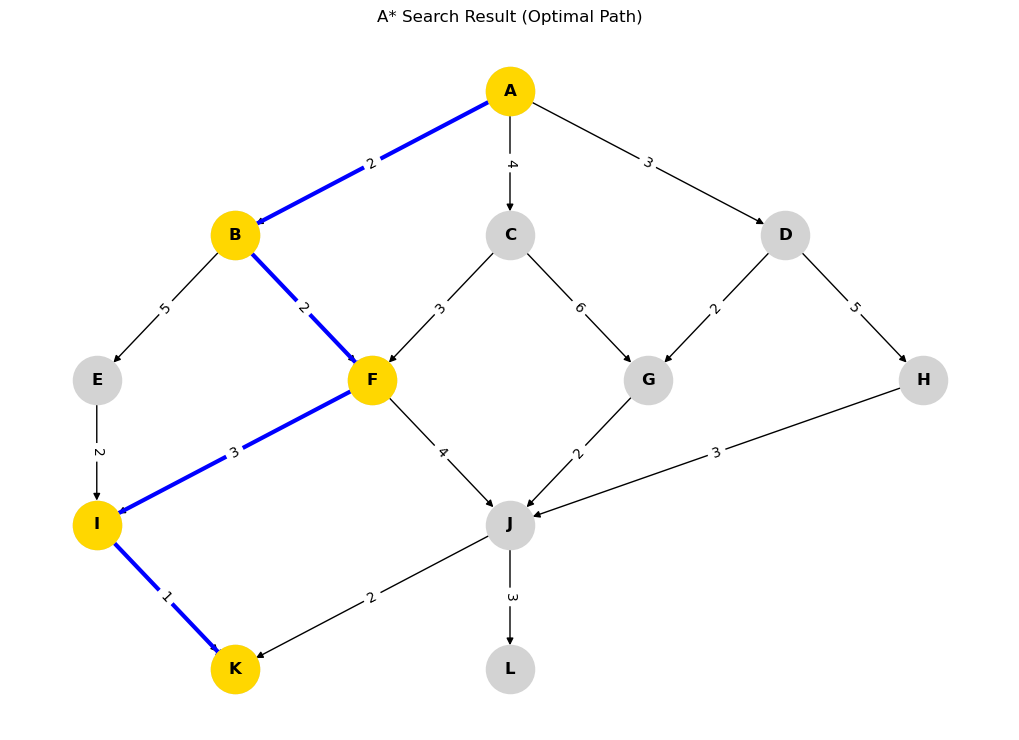

In [20]:
#TASK 05 Part 02
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Graph and Heuristics defined as per Task 5 image
graph = {
    'A': {'B': 2, 'C': 4, 'D': 3},
    'B': {'E': 5, 'F': 2},
    'C': {'F': 3, 'G': 6},
    'D': {'G': 2, 'H': 5},
    'E': {'I': 2},
    'F': {'I': 3, 'J': 4},
    'G': {'J': 2},
    'H': {'J': 3},
    'I': {'K': 1},
    'J': {'K': 2, 'L': 3},
    'K': {},
    'L': {}
}

heuristics = {
    'A': 5, 'B': 4, 'C': 4, 'D': 4, 'E': 2, 'F': 2, 
    'G': 2, 'H': 3, 'I': 1, 'J': 1, 'K': 0, 'L': 0
}

def a_star_search(start, goals, graph, h):
    # frontier: (f_score, current_node)
    frontier = [(h[start], start)]
    came_from = {start: None}
    g_score = {start: 0}
    expansion_order = []
    
    while frontier:
        # Pop node with lowest f(n)
        current_f, current = heapq.heappop(frontier)
        expansion_order.append(current)

        if current in goals:
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[path[0]], expansion_order

        for neighbor, cost in graph[current].items():
            tentative_g = g_score[current] + cost
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                f_score = tentative_g + h[neighbor]
                heapq.heappush(frontier, (f_score, neighbor))
                came_from[neighbor] = current
                
    return None, 0, expansion_order

def visualize_a_star(graph, path, title):
    G = nx.DiGraph()
    for node, neighbors in graph.items():
        for neighbor, weight in neighbors.items():
            G.add_edge(node, neighbor, weight=weight)
            
    pos = {
        'A': (2, 5), 'B': (1, 4), 'C': (2, 4), 'D': (3, 4),
        'E': (0.5, 3), 'F': (1.5, 3), 'G': (2.5, 3), 'H': (3.5, 3),
        'I': (0.5, 2), 'J': (2, 2), 'K': (1, 1), 'L': (2, 1)
    }
    
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos, with_labels=True, node_color='lightgray', node_size=1200, font_weight='bold')
    
    if path:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='gold', node_size=1200)
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=3)
        
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels) # Fixed function name
    plt.title(title)
    plt.show()

# Execution
path, total_cost, expansions = a_star_search('A', ['K', 'L'], graph, heuristics)

print(f"Order of Node Expansions: {expansions}")
print(f"Optimal Path: {' -> '.join(path)}")
print(f"Total Path Cost: {total_cost}")

visualize_a_star(graph, path, "A* Search Result (Optimal Path)")

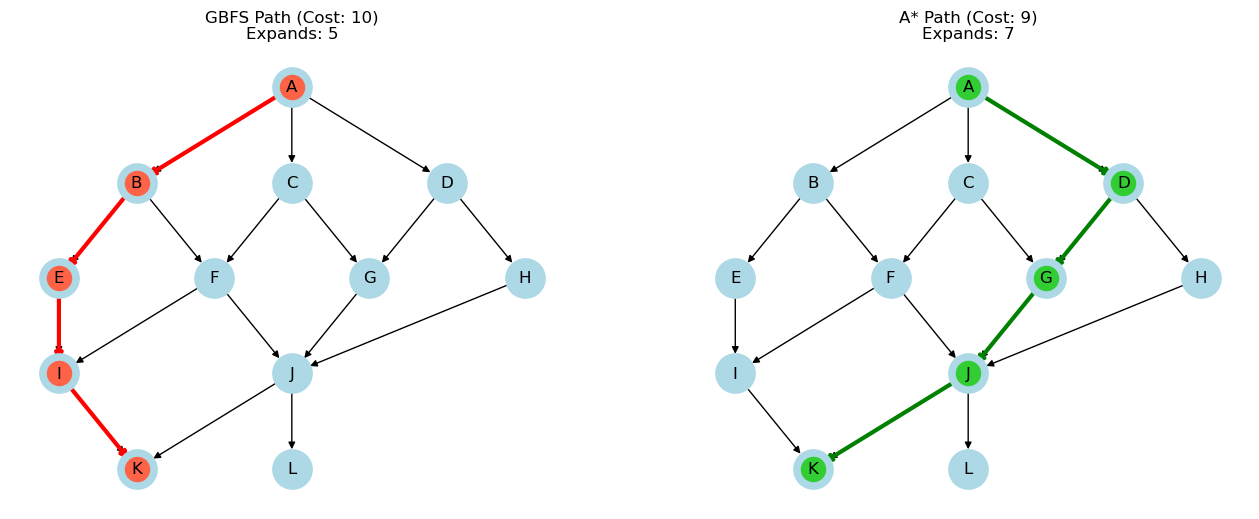

In [21]:
#TASK 05 Part 03
import networkx as nx
import matplotlib.pyplot as plt

# Graph Data
graph = {
    'A': {'B': 2, 'C': 4, 'D': 3}, 'B': {'E': 5, 'F': 2},
    'C': {'F': 3, 'G': 6}, 'D': {'G': 2, 'H': 5},
    'E': {'I': 2}, 'F': {'I': 3, 'J': 4},
    'G': {'J': 2}, 'H': {'J': 3},
    'I': {'K': 1}, 'J': {'K': 2, 'L': 3},
    'K': {}, 'L': {}
}

# Calculated Paths
gbfs_path = ['A', 'B', 'E', 'I', 'K']
astar_path = ['A', 'D', 'G', 'J', 'K']

def draw_comparison(graph, gbfs, astar):
    G = nx.DiGraph()
    for node, edges in graph.items():
        for neighbor, weight in edges.items():
            G.add_edge(node, neighbor, weight=weight)

    pos = {'A': (2, 5), 'B': (1, 4), 'C': (2, 4), 'D': (3, 4),
           'E': (0.5, 3), 'F': (1.5, 3), 'G': (2.5, 3), 'H': (3.5, 3),
           'I': (0.5, 2), 'J': (2, 2), 'K': (1, 1), 'L': (2, 1)}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot GBFS
    nx.draw(G, pos, ax=ax1, with_labels=True, node_color='lightblue', node_size=800)
    gbfs_edges = list(zip(gbfs, gbfs[1:]))
    nx.draw_networkx_nodes(G, pos, ax=ax1, nodelist=gbfs, node_color='tomato')
    nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=gbfs_edges, edge_color='red', width=3)
    ax1.set_title(f"GBFS Path (Cost: 10)\nExpands: {len(gbfs)}")

    # Plot A*
    nx.draw(G, pos, ax=ax2, with_labels=True, node_color='lightblue', node_size=800)
    astar_edges = list(zip(astar, astar[1:]))
    nx.draw_networkx_nodes(G, pos, ax=ax2, nodelist=astar, node_color='limegreen')
    nx.draw_networkx_edges(G, pos, ax=ax2, edgelist=astar_edges, edge_color='green', width=3)
    ax2.set_title(f"A* Path (Cost: 9)\nExpands: 7")

    plt.show()

draw_comparison(graph, gbfs_path, astar_path)